In [1]:
%pip install librosa
%pip install scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io.wavfile import write
import librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl.metadata (5.6 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached pooch-1.9.0-py3-none-any.whl (67 kB)
Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl (172 kB)
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\apps\anaconda3\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\apps\anaconda3\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


Learning Outcome: The student will understand what a spectrogram is and the bridge between the FFT. They will clarify why spectograms are useful for analysing signals and how different window frames affect the output of the short term fourier transform.

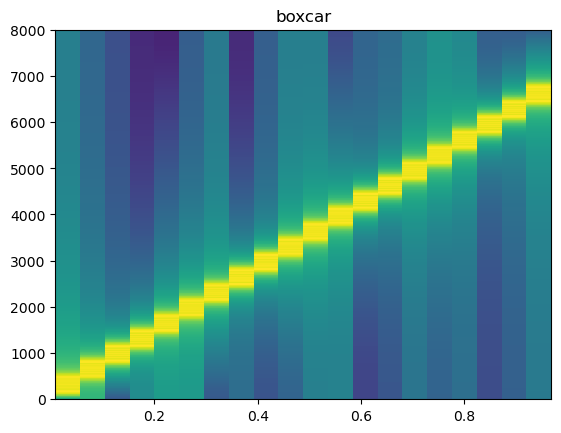

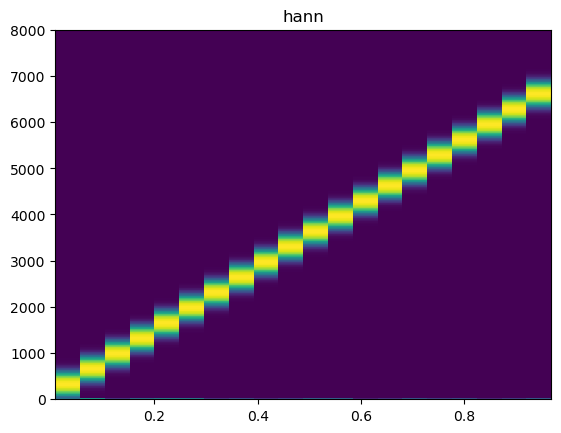

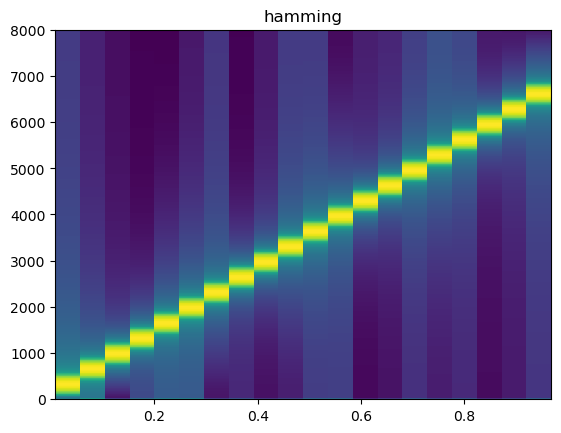

In [7]:
Fs = 16000
dur = 1.0
t = np.linspace(0, dur, int(Fs*dur))
window_type = 'boxcar'
#TODO create a linear chirp signal, starting at a particular frequncy and rising linearly
y_chirp = signal.chirp(t, f0=100, f1=7000, t1=dur, method='linear')

nperseg = 1024 #This is the number of samples
noverlap = nperseg//4 #Represents the number overlap

#TODO Try different window types and compute the spectogram
windows = ['boxcar', 'hann', 'hamming']

#TODO Plot the spectogram with the different window types
for w in windows:
    f, t_spec, Sxx = signal.spectrogram(y_chirp, Fs, window=w, nperseg=nperseg, noverlap=noverlap)
    
    plt.figure()
    plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10))
    plt.title(w)
    plt.savefig(f"{w}.png")
    plt.show()

1) What difference do you notice in the sharpness and smoothness of the chirp line as you change the window? Explain how the window length and shape affect frequency resolution and time resolution.


Learning Outcomes: Use real audio such as a piano song to observe the frequencies that the signal is composed of. The student will observe and match the audio with the spectrogram which will clarify their understanding. In addition they will filter and alter the audio by using the inverse FFT and then listen to the affect of masking different frequencies. The students should be encouraged to use a piece fo music which they enjoy and recognise to observe the effects of signal filtering clearly.


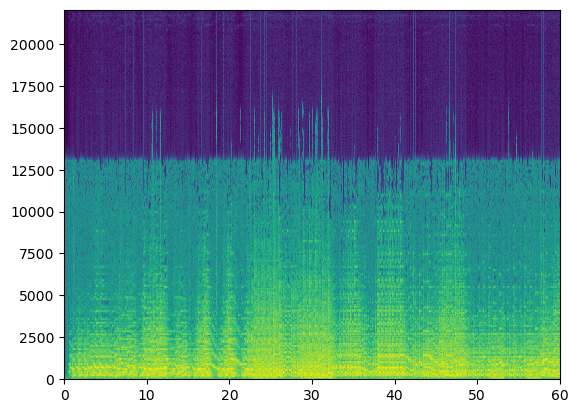

Reconstruction Error: 4.342458126409342e-16


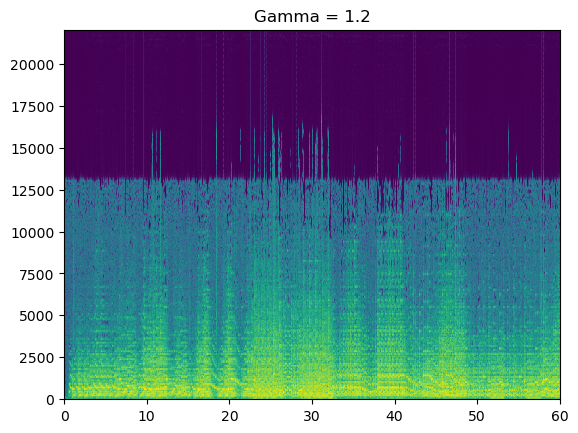

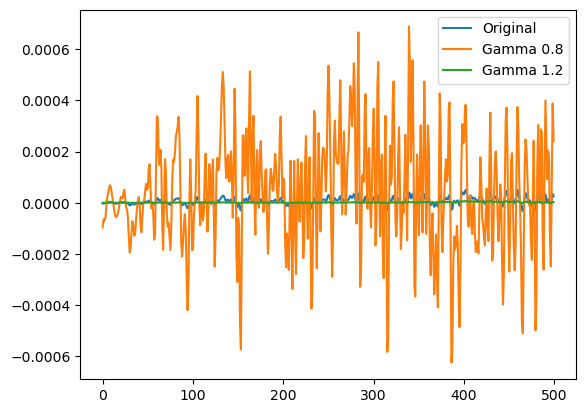

In [8]:
AUDIO_PATH = "Ludwig_van_Beethoven_-_Sonata_Op._31_No._2_(The_Tempest)_-_Third_Movement.ogg" 

def load_audio(path):
    try:
        y, fs = librosa.load(path, sr=None, mono=True)
        return fs, y.astype(np.float64)
    except Exception:
        fs = 16_000
        t = np.linspace(0, 2.0, int(fs*2.0), endpoint=False)
        y = signal.chirp(t, f0=200, f1=2000, t1=2.0, method="linear")
        print("Note: could not read file; using a synthetic chirp instead.")
        return fs, y

fs, y = load_audio(AUDIO_PATH)

Tmax = min(len(y)/fs, 60.0)
y = y[:int(Tmax*fs)]

# TODO Compute and create a spectogram
f, t_stft, Zxx = signal.stft(y, fs, nperseg=1024, noverlap=256)

# TODO Plot log-spectrogram
plt.figure()
plt.pcolormesh(t_stft, f, 10 * np.log10(np.abs(Zxx) + 1e-10))
plt.savefig("spect0.png")
plt.show()

# TODO Invert the spectogram
_, y_inv = signal.istft(Zxx, fs, nperseg=1024, noverlap=256)

# TODO pad/truncate to original length for error metric
if len(y_inv) > len(y):
    y_inv = y_inv[:len(y)]
else:
    y_inv = np.pad(y_inv, (0, len(y) - len(y_inv)))
    
error = np.linalg.norm(y - y_inv) / np.linalg.norm(y)
print("Reconstruction Error:", error)

# TODO enhance the magnitude of the original signal by 0.8 and 1.2
mag = np.abs(Zxx)
phase = np.exp(1j * np.angle(Zxx))
Zxx_08 = (mag ** 0.8) * phase
Zxx_12 = (mag ** 1.2) * phase

# TODO plot the new spectogram
plt.figure()
plt.pcolormesh(t_stft, f, 10 * np.log10(np.abs(Zxx_12) + 1e-10))
plt.title("Gamma = 1.2")
plt.savefig("spect1")
plt.show()

# TODO use inverse istft and listen to output
_, y_08 = signal.istft(Zxx_08, fs, nperseg=1024, noverlap=256)
_, y_12 = signal.istft(Zxx_12, fs, nperseg=1024, noverlap=256)
write("output_istft_12.wav", fs, y_12.astype(np.float32))

# TODO plot the istft
plt.figure()
plt.plot(y[:500], label='Original')
plt.plot(y_08[:500], label='Gamma 0.8')
plt.plot(y_12[:500], label='Gamma 1.2')
plt.legend()
plt.savefig("spect2")
plt.show()

Apply spectral gamma with 0.8 and 1.2, reconstruct audio, RMS-normalise both to the original, and compare spectrograms and short waveform snippets.
1) Which gamma compresses vs expands spectral dynamic range? Describe audible changes and relate them to changes you observe in the spectrogram.

Learning Outcomes: The aim is to provide a clear understanding of modulation and the difference between AM and FM. This practice is concise to allow a practical implementation of a carrier and message frequency.


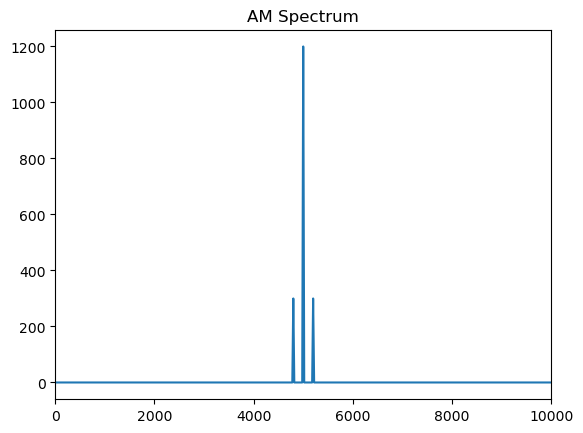

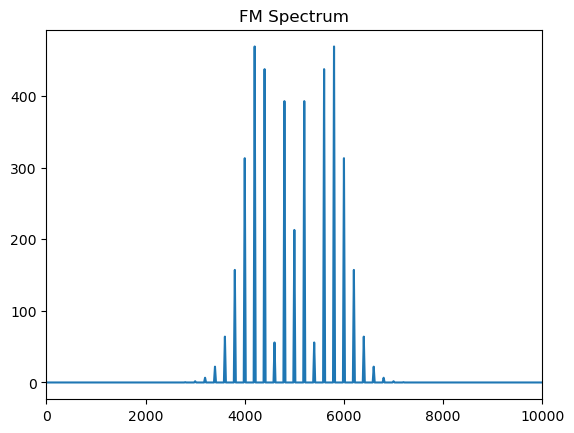

In [9]:
Fs = 48_000
T  = 0.05
t  = np.linspace(0, T, int(Fs*T), endpoint=False)


fm = 200.0                        # message frequency
m  = np.sin(2*np.pi*fm*t)         # message
    
fc = 5000.0                      # carrier
carrier = np.cos(2*np.pi*fc*t)

#TODO compute the amplitude modulation
am_sig = (1 + 0.5 * m) * carrier

#TODO compute the frequency modulation
beta = 5.0
fm_sig = np.cos(2*np.pi*fc*t + beta * np.sin(2*np.pi*fm*t))

#TODO plot the amplitude modulation
am_spec = np.abs(np.fft.fft(am_sig))
freqs = np.fft.fftfreq(len(t), 1/Fs)

plt.figure()
plt.plot(freqs[:len(freqs)//2], am_spec[:len(freqs)//2])
plt.xlim(0, 10000)
plt.title("AM Spectrum")
plt.savefig("am.png")
plt.show()

#TODO plot the frequency modulation
fm_spec = np.abs(np.fft.fft(fm_sig))

plt.figure()
plt.plot(freqs[:len(freqs)//2], fm_spec[:len(freqs)//2])
plt.xlim(0, 10000)
plt.title("FM Spectrum")
plt.savefig("fm.png")
plt.show()

Explain why the FM spectrum is wider even though the message frequency is the same as in AM.


Learning Outcomes: The student should record their own voice for the voiced and unvoiced phonemes and use this audio to compute the zero crossing rate. The zero crossing rate and energy of the signal will demonstrate the difference between voiced and unvoiced phonemes by the signal oscillation.

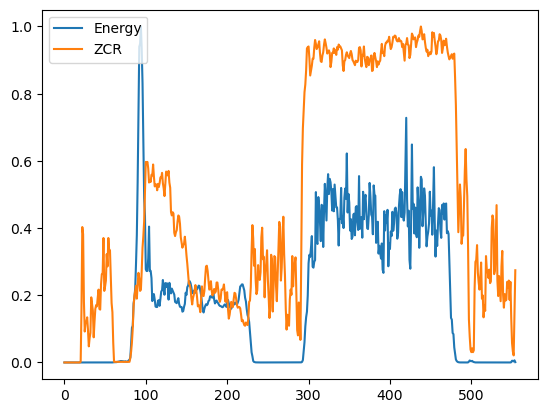

In [10]:
AUDIO_PATH = "Recording.wav"
def load_audio(path):

    try:
        y, fs = librosa.load(path, sr=None, mono=True)
        return fs, y.astype(float)
    except Exception:
        print("Could not read file; falling back to synthetic.")
        return 16000, np.random.randn(16000)

# TODO Upload your audio of voiced vs unvoiced phonemes
fs, x = load_audio(AUDIO_PATH)


frame_ms = 25
hop_ms   = 10
Nf = int(fs*frame_ms/1000)
H  = int(fs*hop_ms/1000)
win = np.hanning(Nf)

#TODO iterate through a for loop to compute the hanns frame
num_frames = (len(x) - Nf) // H + 1
energy = np.zeros(num_frames)
zcr = np.zeros(num_frames)

for i in range(num_frames):
    start = i * H
    frame = x[start:start+Nf] * win
    
    #TODO Compute the energy and the zcr and plot this
    energy[i] = np.sum(frame**2)
    zcr[i] = np.sum(np.abs(np.diff(np.sign(frame)))) / (2 * Nf)

energy = energy / np.max(energy)
zcr = zcr / np.max(zcr)

plt.figure()
plt.plot(energy, label="Energy")
plt.plot(zcr, label="ZCR")
plt.legend()
plt.savefig("energy_zcr.png")
plt.show()

Identify areas on the graph that are voiced and unvoiced phonemes and briefly explain why this is.


Learning Outcome: By the end of this section, students will be able to use an FFT to show that narrowing a wavefunction in position broadens its spectrum in k, and relate this to the uncertainty bound $\Delta$ $x$ $\,$ $\Delta$ p $\ge$ $\hbar/2$ via $p=\hbar k$.

Gaussian sigma_x= 0.5: delta x=0.5000, delta k=1.0000, delta x delta k=0.5000 
Gaussian sigma_x= 2.0: delta x=2.0000, delta k=0.2500, delta x delta k=0.5000 
Gaussian sigma_x=10.0: delta x=10.0000, delta k=0.0500, delta x delta k=0.5000 


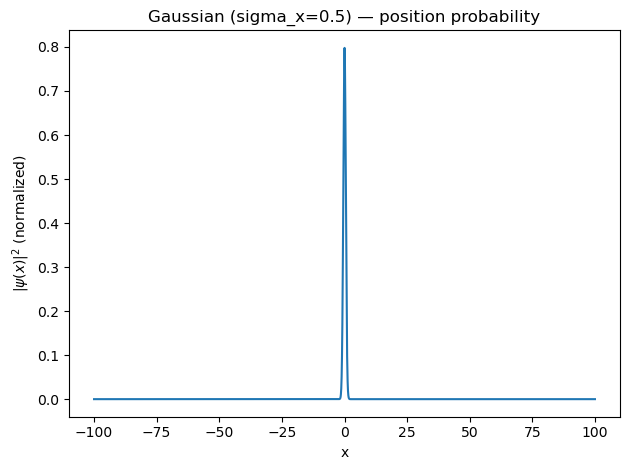

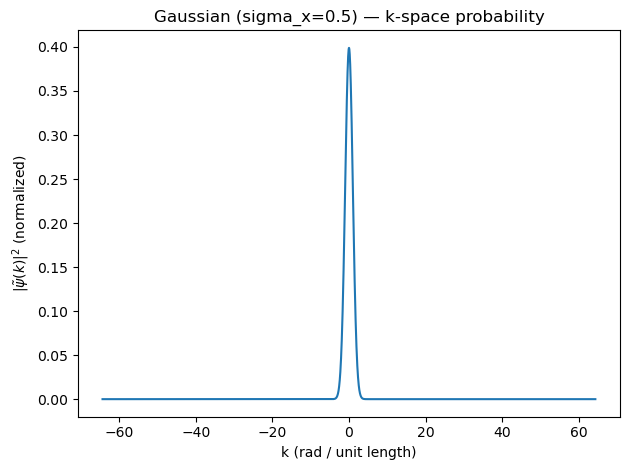

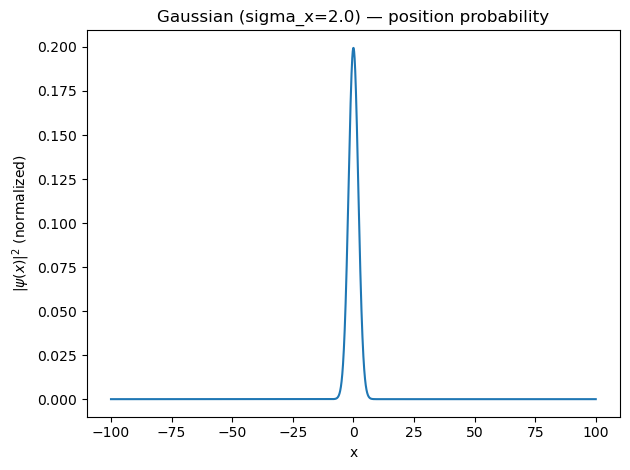

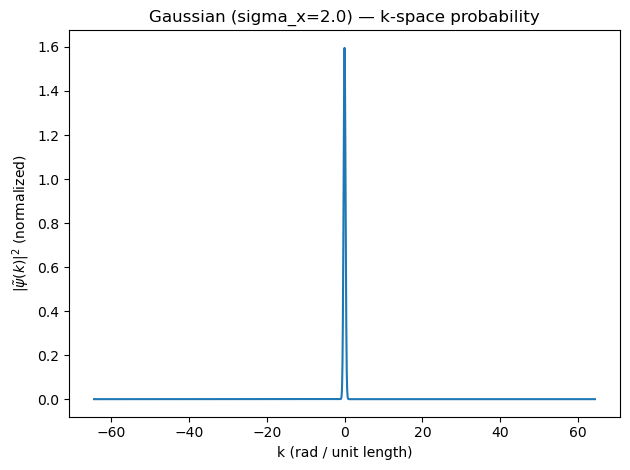

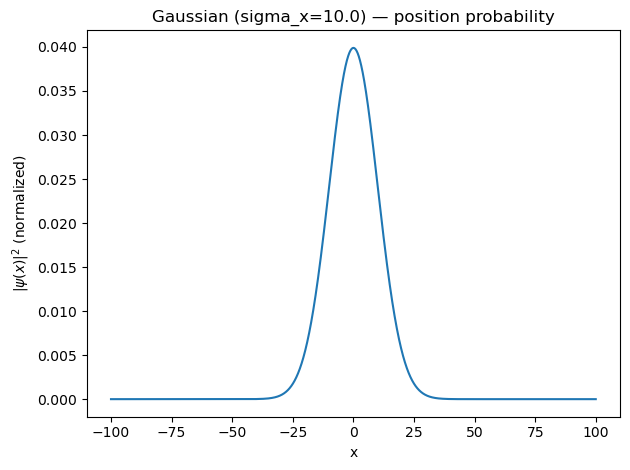

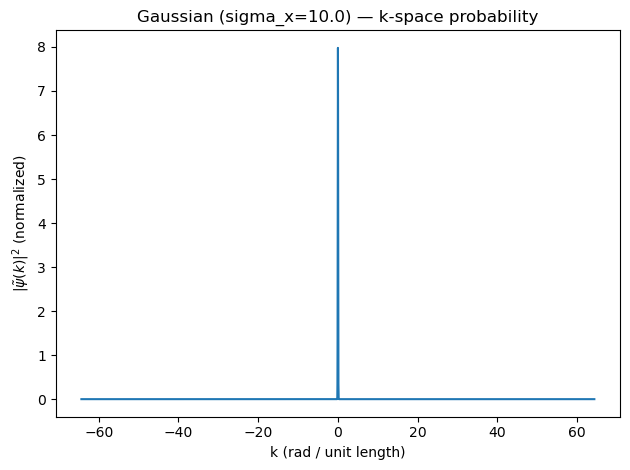

In [16]:
def normalize_probability_density(pdf, dx):
    area = np.sum(pdf) * dx
    return pdf / area


def mean_and_std(x, pdf, dx):
    """Compute mean and standard deviation of x under pdf using Riemann sums."""
    pdf = normalize_probability_density(pdf, dx)
    mu = np.sum(x * pdf) * dx
    var = np.sum((x - mu) ** 2 * pdf) * dx
    return mu, np.sqrt(var)


def k_grid(N, dx):
    """
    FFT frequency grid in angular wavenumber k [rad / unit length].
    numpy.fft.fftfreq gives cycles/unit then multiply by 2 pi to get rad/unit.
    """
    f = np.fft.fftfreq(N, d=dx)
    k = 2 * np.pi * f
    return np.fft.fftshift(k)


def fft_k_space(psi_x, dx):
    """
    Compute a k-space wavefunction from psi(x) using FFT.
    """
    psi_k = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(psi_x))) * dx / np.sqrt(2*np.pi)
    return psi_k


def make_gaussian_packet(x, sigma_x, k0=0.0):
    psi = np.exp(-(x**2) / (4 * sigma_x**2)) * np.exp(1j * k0 * x)
    return psi


def report_uncertainties(x, psi_x, hbar=1.0):
    """
    Compute delta x from |psi(x)|^2 and delta k from |psi(k)|^2, then delta p = h_bar delta k.
    Returns (dx_std, dk_std, dp_std, product_dx_dk, product_dx_dp, k, pk, px).
    """
    N = x.size
    dx = x[1] - x[0]
    k = k_grid(N, dx)
    dk = k[1] - k[0]

    # Position space probability
    px = np.abs(psi_x)**2
    px = normalize_probability_density(px, dx)
    _, dx_std = mean_and_std(x, px, dx)

    #  k-space probability
    psi_k = fft_k_space(psi_x, dx)
    pk = np.abs(psi_k)**2
    pk = normalize_probability_density(pk, dk)
    _, dk_std = mean_and_std(k, pk, dk)

    #  Translate to momentum
    dp_std = hbar * dk_std

    return dx_std, dk_std, dp_std, dx_std * dk_std, dx_std * dp_std, k, pk, px


def plot_x_and_k(x, px, k, pk, title):
    plt.figure()
    plt.plot(x, px)
    plt.xlabel("x")
    plt.ylabel(r"$|\psi(x)|^2$ (normalized)")
    plt.title(title + " — position probability")
    plt.tight_layout()

    plt.figure()
    plt.plot(k, pk)
    plt.xlabel("k (rad / unit length)")
    plt.ylabel(r"$|\tilde{\psi}(k)|^2$ (normalized)")
    plt.title(title + " — k-space probability")
    plt.tight_layout()


# TODO try changing N and L and see how it affects resolution in x and k.
N = 2**12          # 4096 points
L = 200.0          # domain length in x-units
dx = L / N
x = (np.arange(N) - N/2) * dx

hbar = 1.0

sigmas = [0.5, 2.0, 10.0]
for sigma_x in sigmas:
    # TODO generate psi(x) for each sigma_x
    psi_x = make_gaussian_packet(x, sigma_x)

    # TODO compute uncertainties in x and k and momentum
    dx_std, dk_std, dp_std, prod_xk, prod_xp, k, pk, px = report_uncertainties(x, psi_x, hbar)

    print(f"Gaussian sigma_x={sigma_x:>4}: delta x={dx_std:.4f}, delta k={dk_std:.4f}, delta x delta k={prod_xk:.4f} ")
    plot_x_and_k(x, px, k, pk, title=f"Gaussian (sigma_x={sigma_x})")


plt.show()

1. As $\sigma_x$ decreases what happens to $\Delta k$? Is it roughly inverse to $\Delta x$?

2. For the Gaussian cases, what do you get for $\Delta x\,\Delta k$? How close is it to $1/2$?

3. Using $p=\hbar k$, compute $\Delta p$. Verify whether $\Delta x\,\Delta p \ge \hbar/2$ holds (here $\hbar=1$).

4. Explain breifly how this relates to heisenberg's uncertainty principle.